<a href="https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-21-information-theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 21. Information Theory and Language

This lab accompanies **Chapter 21: Information Theory and Language** in *The Mathematics of Natural Language Processing*.

Information theory gives a mathematical language for uncertainty, prediction, compression, dependence, and representation. In NLP, these ideas appear in language-model training, perplexity, tokenization, retrieval, embeddings, fine-tuning, and alignment.

The central connection is:

$$
\text{good probability prediction} \quad \Longleftrightarrow \quad \text{short average code length}.
$$

In this lab, you will build the main quantities from scratch and apply them to small language examples.

## Learning goals

By the end of this lab, you should be able to:

1. compute entropy, surprisal, cross-entropy, KL divergence, and perplexity;
2. explain why cross-entropy is the standard training loss for language models;
3. interpret perplexity as an average branching factor;
4. compare models by average code length;
5. compute conditional entropy for unigram and bigram text models;
6. compute mutual information and pointwise mutual information from count tables;
7. explain why tokenization changes the numerical scale of entropy and perplexity;
8. interpret KL regularization as a distributional trust region;
9. audit information-theoretic calculations for support mismatch and rare-event instability;
10. complete a mini-project profiling the information structure of a small corpus.

## Colab notes

This notebook uses only `numpy`, `pandas`, and `matplotlib`, which are available in Google Colab. No external data or API key is required.


## 1. Setup

Run this cell first. We fix a random seed so that examples are reproducible.


In [1]:
import math
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

rng = np.random.default_rng(7243)
np.set_printoptions(precision=4, suppress=True)

print("Setup complete.")


Setup complete.


## 2. From text to an empirical token distribution

Let $V=\{1,2,\ldots,d\}$ be a vocabulary. A token distribution is a vector

$$
p=(p_1,\ldots,p_d), \qquad p_j \ge 0, \qquad \sum_{j=1}^d p_j=1.
$$

Given token counts $c_1,\ldots,c_d$, the empirical distribution is

$$
\widehat p_j = \frac{c_j}{\sum_{r=1}^d c_r}.
$$

This is the simplest bridge between language and information theory: a corpus becomes a point in the probability simplex.


In [2]:
corpus = """
Language models learn patterns from language data.
Information theory studies uncertainty, compression, and prediction.
A good language model assigns high probability to likely tokens.
A poor model wastes code length by assigning probability to unlikely tokens.
"""

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

tokens = tokenize(corpus)
counts = Counter(tokens)
N = sum(counts.values())
vocab = sorted(counts)
probs = np.array([counts[w] / N for w in vocab])

freq_df = pd.DataFrame({
    "token": vocab,
    "count": [counts[w] for w in vocab],
    "probability": probs,
}).sort_values(["count", "token"], ascending=[False, True]).reset_index(drop=True)

print("Number of tokens:", N)
print("Vocabulary size:", len(vocab))
display(freq_df.head(12))
print("Probability sum:", probs.sum())


Number of tokens: 36
Vocabulary size: 29


,token,count,probability
0,language,3,0.083333
1,a,2,0.055556
2,model,2,0.055556
3,probability,2,0.055556
4,to,2,0.055556
5,tokens,2,0.055556
6,and,1,0.027778
7,assigning,1,0.027778
8,assigns,1,0.027778
9,by,1,0.027778


Probability sum: 1.0


### Checkpoint question

Which tokens dominate this small corpus? Do you expect the entropy to be close to $0$, close to $\log |V|$, or somewhere in between?


## 3. Surprisal and entropy

The **surprisal** of an event $X=x$ is

$$
I(x)=-\log p(x).
$$

Rare events have high surprisal. Common events have low surprisal.

The **entropy** of a discrete distribution is

$$
H(p)=-\sum_j p_j \log p_j.
$$

Equivalently, entropy is average surprisal:

$$
H(X)=E[-\log p(X)].
$$

Natural logarithms give units of **nats**. Base-$2$ logarithms give units of **bits**.


In [3]:
def safe_normalize(x):
    x = np.asarray(x, dtype=float)
    total = x.sum()
    if total <= 0:
        raise ValueError("The vector must have positive total mass.")
    return x / total


def entropy(p, base=math.e):
    p = safe_normalize(p)
    positive = p[p > 0]
    h_nats = -np.sum(positive * np.log(positive))
    if base == math.e:
        return float(h_nats)
    return float(h_nats / np.log(base))


def surprisal_table(tokens, counts):
    N = sum(counts.values())
    rows = []
    for w, c in sorted(counts.items(), key=lambda item: (-item[1], item[0])):
        p = c / N
        rows.append({
            "token": w,
            "p(token)": p,
            "surprisal_nats": -math.log(p),
            "surprisal_bits": -math.log2(p),
        })
    return pd.DataFrame(rows)

H_nats = entropy(probs)
H_bits = entropy(probs, base=2)
H_uniform = math.log(len(vocab))

print("Entropy:", round(H_nats, 4), "nats")
print("Entropy:", round(H_bits, 4), "bits")
print("Maximum entropy on this vocabulary:", round(H_uniform, 4), "nats")
print("Empirical perplexity exp(H):", round(math.exp(H_nats), 4))

display(surprisal_table(tokens, counts).head(10))


Entropy: 3.2994 nats
Entropy: 4.7601 bits
Maximum entropy on this vocabulary: 3.3673 nats
Empirical perplexity exp(H): 27.0971


,token,p(token),surprisal_nats,surprisal_bits
0,language,0.083333,2.484907,3.584963
1,a,0.055556,2.890372,4.169925
2,model,0.055556,2.890372,4.169925
3,probability,0.055556,2.890372,4.169925
4,to,0.055556,2.890372,4.169925
5,tokens,0.055556,2.890372,4.169925
6,and,0.027778,3.583519,5.169925
7,assigning,0.027778,3.583519,5.169925
8,assigns,0.027778,3.583519,5.169925
9,by,0.027778,3.583519,5.169925


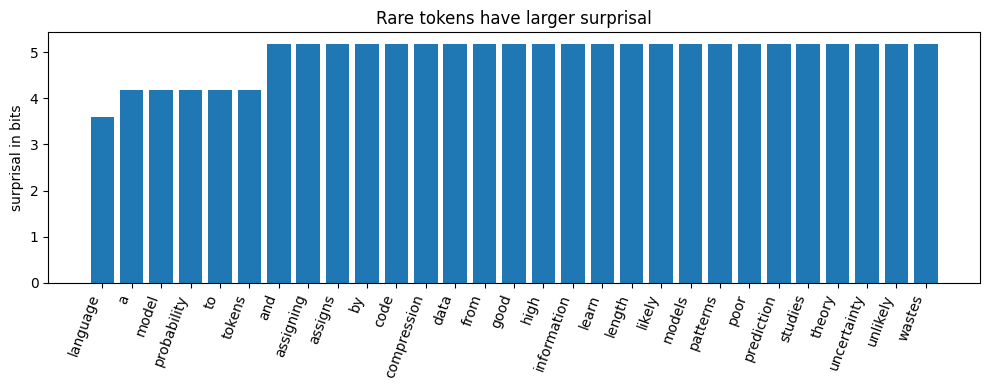

In [4]:
# Visualize surprisal for all tokens.
st = surprisal_table(tokens, counts).sort_values("surprisal_bits")

plt.figure(figsize=(10, 4))
plt.bar(st["token"], st["surprisal_bits"])
plt.xticks(rotation=70, ha="right")
plt.ylabel("surprisal in bits")
plt.title("Rare tokens have larger surprisal")
plt.tight_layout()
plt.show()


## 4. Entropy changes with distribution shape

For a fixed vocabulary size $d$, entropy is smallest when probability mass is concentrated on one token and largest for the uniform distribution.

A useful family of toy distributions is the softmax-temperature family:

$$
p_j(T)=\frac{\exp(s_j/T)}{\sum_r \exp(s_r/T)}.
$$

Small $T$ makes the distribution sharp. Large $T$ makes it more uniform.


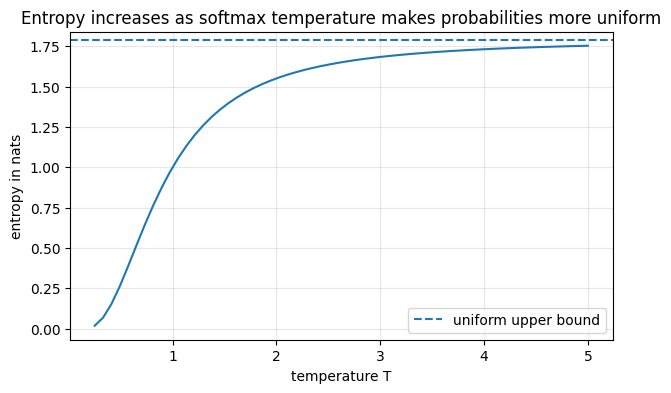

T=0.3: p=[0.993 0.007 0.    0.    0.    0.   ], H=0.045, PPL=1.046
T=1.0: p=[0.697 0.156 0.07  0.042 0.023 0.012], H=1.000, PPL=2.718
T=4.0: p=[0.283 0.195 0.159 0.141 0.121 0.102], H=1.732, PPL=5.652


In [5]:
def softmax(x):
    x = np.asarray(x, dtype=float)
    z = x - x.max()
    e = np.exp(z)
    return e / e.sum()

scores = np.array([3.5, 2.0, 1.2, 0.7, 0.1, -0.6])
temps = np.linspace(0.25, 5.0, 60)
entropies = np.array([entropy(softmax(scores / T)) for T in temps])

plt.figure(figsize=(7, 4))
plt.plot(temps, entropies)
plt.axhline(math.log(len(scores)), linestyle="--", label="uniform upper bound")
plt.xlabel("temperature T")
plt.ylabel("entropy in nats")
plt.title("Entropy increases as softmax temperature makes probabilities more uniform")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for T in [0.3, 1.0, 4.0]:
    pT = softmax(scores / T)
    print(f"T={T}: p={np.round(pT, 3)}, H={entropy(pT):.3f}, PPL={math.exp(entropy(pT)):.3f}")


### Exercise 1

Change the vector `scores`. Create one example where entropy is very low and one example where entropy is close to $\log d$.


## 5. Cross-entropy, KL divergence, and support mismatch

Suppose the true distribution is $p$ but a model predicts $q$. The cross-entropy is

$$
H(p,q)=-\sum_j p_j \log q_j.
$$

The KL divergence is

$$
D_{KL}(p \| q)=\sum_j p_j \log\frac{p_j}{q_j}.
$$

These quantities satisfy

$$
H(p,q)=H(p)+D_{KL}(p \| q).
$$

So cross-entropy is entropy plus the extra cost of using the wrong distribution.


In [6]:
def cross_entropy(p, q, base=math.e):
    p = safe_normalize(p)
    q = safe_normalize(q)
    if np.any((p > 0) & (q == 0)):
        return float("inf")
    mask = p > 0
    h_nats = -np.sum(p[mask] * np.log(q[mask]))
    if base == math.e:
        return float(h_nats)
    return float(h_nats / np.log(base))


def kl_divergence(p, q, base=math.e):
    ce = cross_entropy(p, q, base=base)
    if math.isinf(ce):
        return float("inf")
    return ce - entropy(p, base=base)


def perplexity_from_ce(ce_nats):
    return math.exp(ce_nats)

p = np.array([0.45, 0.30, 0.20, 0.05])
q_good = np.array([0.40, 0.32, 0.20, 0.08])
q_bad = np.array([0.10, 0.20, 0.30, 0.40])
q_zero = np.array([0.50, 0.50, 0.00, 0.00])
labels = ["machine", "language", "data", "model"]

rows = []
for name, q in [("good model", q_good), ("bad model", q_bad), ("zero-support model", q_zero)]:
    ce = cross_entropy(p, q)
    kl = kl_divergence(p, q)
    rows.append({
        "model": name,
        "H(p,q) nats": ce,
        "KL(p||q) nats": kl,
        "perplexity": perplexity_from_ce(ce) if math.isfinite(ce) else float("inf"),
    })

display(pd.DataFrame(rows))
print("H(p):", round(entropy(p), 4))


,model,"H(p,q) nats",KL(p||q) nats,perplexity
0,good model,1.202335,0.010141,3.327879
1,bad model,1.805604,0.613409,6.083643
2,zero-support model,inf,inf,inf


H(p): 1.1922


The zero-support model assigns probability $0$ to events that occur under $p$. This makes the cross-entropy infinite. This is the information-theoretic version of the zero-probability problem in n-gram language models.

A simple fix is additive smoothing:

$$
q_j^{(\alpha)}=\frac{c_j+\alpha}{\sum_r c_r+\alpha d}.
$$


In [7]:
counts_model = np.array([12, 8, 0, 0])
for alpha in [0.0, 0.1, 0.5, 1.0, 5.0]:
    q = (counts_model + alpha) / (counts_model.sum() + alpha * len(counts_model))
    ce = cross_entropy(p, q)
    print(f"alpha={alpha:>3}: q={np.round(q, 3)}, cross-entropy={ce}, KL={kl_divergence(p, q)}")


alpha=0.0: q=[0.6 0.4 0.  0. ], cross-entropy=inf, KL=inf
alpha=0.1: q=[0.593 0.397 0.005 0.005], cross-entropy=1.8416795019239511, KL=0.6494850011636535
alpha=0.5: q=[0.568 0.386 0.023 0.023], cross-entropy=1.485731509510706, KL=0.29353700875040833
alpha=1.0: q=[0.542 0.375 0.042 0.042], cross-entropy=1.364659246289388, KL=0.1724647455290904
alpha=5.0: q=[0.425 0.325 0.125 0.125], cross-entropy=1.242089163941653, KL=0.04989466318135527


### Exercise 2

Explain why very large smoothing can also hurt. What distribution does $q^{(\alpha)}$ approach as $\alpha \to \infty$?


## 6. Perplexity as average branching factor

For observed tokens $x_1,\ldots,x_n$, suppose a language model assigns probabilities

$$
q_i=q(x_i \mid x_{<i}).
$$

The average negative log-likelihood is

$$
\text{NLL}_{avg}=-\frac{1}{n}\sum_i \log q_i.
$$

The perplexity is

$$
\text{PPL}=\exp(\text{NLL}_{avg}).
$$

A perplexity of $20$ means that the model is, in an information-theoretic sense, as uncertain as if it were choosing uniformly among about $20$ equally likely next tokens.


In [8]:
# A held-out sequence and two toy next-token probability assignments.
observed = ["data", "model", "data", "language", "model", "data", "tokens", "model"]
model_A_probs = [0.55, 0.35, 0.50, 0.20, 0.38, 0.48, 0.08, 0.36]
model_B_probs = [0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25]

def average_nll_and_ppl(probs):
    probs = np.asarray(probs, dtype=float)
    avg_nll = -np.mean(np.log(probs))
    return avg_nll, math.exp(avg_nll)

for name, probs_assigned in [("Model A", model_A_probs), ("Model B", model_B_probs)]:
    avg_nll, ppl = average_nll_and_ppl(probs_assigned)
    bits_per_token = avg_nll / math.log(2)
    print(name)
    print("  average NLL:", round(avg_nll, 4), "nats")
    print("  bits per token:", round(bits_per_token, 4))
    print("  perplexity:", round(ppl, 4))


Model A
  average NLL: 1.1499 nats
  bits per token: 1.659
  perplexity: 3.1579
Model B
  average NLL: 1.3863 nats
  bits per token: 2.0
  perplexity: 4.0


### Important caution

Perplexity depends on the tokenization. A character-level model, word-level model, and subword-level model predict different random variables. Their perplexities are not directly comparable unless the prediction unit is handled carefully.


## 7. Compression viewpoint: average code length

If an event has probability $q(x)$, an ideal code assigns length approximately

$$
\ell(x)=-\log_2 q(x)
$$

bits. The expected code length under true distribution $p$ and code distribution $q$ is the base-$2$ cross-entropy:

$$
H_2(p,q)=-\sum_x p(x)\log_2 q(x).
$$

Thus lower cross-entropy means shorter average code length.


In [9]:
code_df = pd.DataFrame({
    "token": observed,
    "q_A": model_A_probs,
    "bits_A": [-math.log2(x) for x in model_A_probs],
    "q_B": model_B_probs,
    "bits_B": [-math.log2(x) for x in model_B_probs],
})
display(code_df)
print("Average bits, Model A:", round(code_df["bits_A"].mean(), 4))
print("Average bits, Model B:", round(code_df["bits_B"].mean(), 4))
print("Total saved bits by Model A:", round(code_df["bits_B"].sum() - code_df["bits_A"].sum(), 4))


,token,q_A,bits_A,q_B,bits_B
0,data,0.55,0.862496,0.25,2.0
1,model,0.35,1.514573,0.25,2.0
2,data,0.50,1.000000,0.25,2.0
3,language,0.20,2.321928,0.25,2.0
4,model,0.38,1.395929,0.25,2.0
5,data,0.48,1.058894,0.25,2.0
6,tokens,0.08,3.643856,0.25,2.0
7,model,0.36,1.473931,0.25,2.0


Average bits, Model A: 1.659
Average bits, Model B: 2.0
Total saved bits by Model A: 2.7284


## 8. Conditional entropy and bigram language models

The entropy chain rule says

$$
H(W_{1:T})=\sum_{t=1}^T H(W_t \mid W_{1:t-1}).
$$

A bigram model uses only the previous token:

$$
p(w_t \mid w_{1:t-1}) \approx p(w_t \mid w_{t-1}).
$$

If $P$ is a bigram transition matrix and $\pi$ is the empirical distribution of previous tokens, then the bigram conditional entropy is

$$
H(W_t \mid W_{t-1}) = \sum_i \pi_i H(P_{i,\cdot}).
$$


In [10]:
def build_bigram_counts(tokens):
    pairs = list(zip(tokens[:-1], tokens[1:]))
    bigram_counts = Counter(pairs)
    previous_counts = Counter(tokens[:-1])
    vocab_local = sorted(set(tokens))
    return vocab_local, bigram_counts, previous_counts

vocab_bi, bigram_counts, previous_counts = build_bigram_counts(tokens)
index = {w: i for i, w in enumerate(vocab_bi)}
d = len(vocab_bi)
C = np.zeros((d, d), dtype=float)
for (w, nxt), c in bigram_counts.items():
    C[index[w], index[nxt]] = c

alpha = 0.5
P_bigram = (C + alpha) / (C.sum(axis=1, keepdims=True) + alpha * d)
pi_prev = np.array([previous_counts[w] for w in vocab_bi], dtype=float)
pi_prev = pi_prev / pi_prev.sum()
row_H = np.array([entropy(row) for row in P_bigram])
conditional_H = float(np.sum(pi_prev * row_H))

unigram_H = entropy(probs)

print("Unigram entropy:", round(unigram_H, 4), "nats")
print("Bigram conditional entropy:", round(conditional_H, 4), "nats")
print("Unigram perplexity:", round(math.exp(unigram_H), 4))
print("Bigram conditional perplexity:", round(math.exp(conditional_H), 4))

row_df = pd.DataFrame({
    "previous_token": vocab_bi,
    "empirical_weight": pi_prev,
    "H(next | previous)": row_H,
}).sort_values("empirical_weight", ascending=False)
display(row_df.head(12))


Unigram entropy: 3.2994 nats
Bigram conditional entropy: 3.3134 nats
Unigram perplexity: 27.0971
Bigram conditional perplexity: 27.478


,previous_token,empirical_weight,H(next | previous)
12,language,0.085714,3.272848
0,a,0.057143,3.296760
24,to,0.057143,3.296760
21,probability,0.057143,3.252653
16,model,0.057143,3.296760
4,by,0.028571,3.327670
5,code,0.028571,3.327670
7,data,0.028571,3.327670
6,compression,0.028571,3.327670
8,from,0.028571,3.327670


In [11]:
# Show the most likely next tokens for a few contexts.
for context in ["language", "model", "probability", "tokens"]:
    if context in index:
        row = P_bigram[index[context]]
        top = np.argsort(row)[::-1][:5]
        print("Context:", context)
        for j in top:
            print(f"  {vocab_bi[j]:14s} {row[j]:.3f}")


Context: language
  models         0.086
  model          0.086
  data           0.086
  unlikely       0.029
  uncertainty    0.029
Context: model
  wastes         0.091
  assigns        0.091
  unlikely       0.030
  tokens         0.030
  uncertainty    0.030
Context: probability
  to             0.152
  wastes         0.030
  unlikely       0.030
  uncertainty    0.030
  tokens         0.030
Context: tokens
  a              0.097
  unlikely       0.032
  uncertainty    0.032
  tokens         0.032
  wastes         0.032


### Exercise 3

Add two or three more sentences to `corpus`, rerun the unigram and bigram entropy cells, and describe how the conditional entropy changes.


## 9. Mutual information between a token and a label

The conditional entropy $H(Y \mid X)$ measures remaining uncertainty about $Y$ after observing $X$. The mutual information is

$$
I(X;Y)=H(Y)-H(Y\mid X).
$$

Equivalently,

$$
I(X;Y)=\sum_{x,y}p(x,y)\log\frac{p(x,y)}{p(x)p(y)}.
$$

In text classification, $X$ can be a binary feature indicating whether a token appears in a document, and $Y$ can be a class label.


In [12]:
# A tiny document classification data set.
docs = [
    ("great clear helpful explanation", "positive"),
    ("excellent helpful course", "positive"),
    ("clear examples and great notes", "positive"),
    ("confusing unclear lecture", "negative"),
    ("poor explanation and confusing notes", "negative"),
    ("unclear assignment poor feedback", "negative"),
    ("helpful examples but difficult assignment", "positive"),
    ("difficult confusing exam", "negative"),
]

def mi_from_table(table):
    table = np.asarray(table, dtype=float)
    pxy = table / table.sum()
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    expected = px @ py
    mask = pxy > 0
    return float(np.sum(pxy[mask] * np.log(pxy[mask] / expected[mask])))

all_terms = sorted(set(t for text, label in docs for t in tokenize(text)))
labels_cls = sorted(set(label for text, label in docs))
label_index = {y: j for j, y in enumerate(labels_cls)}

rows = []
for term in all_terms:
    table = np.zeros((2, 2), dtype=float)  # absent/present by label
    for text, label in docs:
        present = int(term in set(tokenize(text)))
        table[present, label_index[label]] += 1
    rows.append({"term": term, "MI(term; label)": mi_from_table(table), "table": table.astype(int).tolist()})

mi_df = pd.DataFrame(rows).sort_values("MI(term; label)", ascending=False).reset_index(drop=True)
display(mi_df[["term", "MI(term; label)", "table"]])


,term,MI(term; label),table
0,helpful,0.380396,"[[4, 1], [0, 3]]"
1,confusing,0.380396,"[[1, 4], [3, 0]]"
2,unclear,0.215762,"[[2, 4], [2, 0]]"
3,poor,0.215762,"[[2, 4], [2, 0]]"
4,examples,0.215762,"[[4, 2], [0, 2]]"
5,clear,0.215762,"[[4, 2], [0, 2]]"
6,great,0.215762,"[[4, 2], [0, 2]]"
7,excellent,0.095603,"[[4, 3], [0, 1]]"
8,lecture,0.095603,"[[3, 4], [1, 0]]"
9,but,0.095603,"[[4, 3], [0, 1]]"


### Exercise 4

Why do words like `helpful`, `poor`, or `confusing` tend to have larger mutual information with the label than words like `and` or `assignment`? What can go wrong when a rare word appears only once?


## 10. Pointwise mutual information and word-context counts

For two events $X=x$ and $Y=y$, the pointwise mutual information is

$$
PMI(x,y)=\log\frac{p(x,y)}{p(x)p(y)}.
$$

PMI is positive when two events occur together more often than expected under independence. In word-context analysis,

$$
PMI(w,c)=\log\frac{p(w,c)}{p(w)p(c)}.
$$

The positive part is

$$
PPMI(w,c)=\max(PMI(w,c),0).
$$


In [13]:
words = ["king", "queen", "bank", "river", "model"]
contexts = ["royal", "money", "water", "data"]
co_counts = np.array([
    [10,  1,  0,  0],
    [ 9,  1,  0,  0],
    [ 0,  8,  5,  1],
    [ 0,  1, 10,  0],
    [ 0,  1,  0, 12],
], dtype=float)

N_wc = co_counts.sum()
p_wc = co_counts / N_wc
p_w = p_wc.sum(axis=1, keepdims=True)
p_c = p_wc.sum(axis=0, keepdims=True)
expected = p_w @ p_c

with np.errstate(divide="ignore", invalid="ignore"):
    PMI = np.log(p_wc / expected)
PMI_masked = np.where(co_counts > 0, PMI, np.nan)
PPMI = np.where(np.isnan(PMI_masked), 0.0, np.maximum(PMI_masked, 0.0))

print("PMI matrix")
display(pd.DataFrame(PMI_masked, index=words, columns=contexts).round(3))
print("PPMI matrix")
display(pd.DataFrame(PPMI, index=words, columns=contexts).round(3))


PMI matrix


,royal,money,water,data
king,1.038,-0.805,NaN,NaN
queen,1.028,-0.710,NaN,NaN
bank,NaN,1.033,0.340,-1.126
river,NaN,-0.805,1.274,NaN
model,NaN,-0.972,NaN,1.433


PPMI matrix


,royal,money,water,data
king,1.038,0.000,0.000,0.000
queen,1.028,0.000,0.000,0.000
bank,0.000,1.033,0.340,0.000
river,0.000,0.000,1.274,0.000
model,0.000,0.000,0.000,1.433


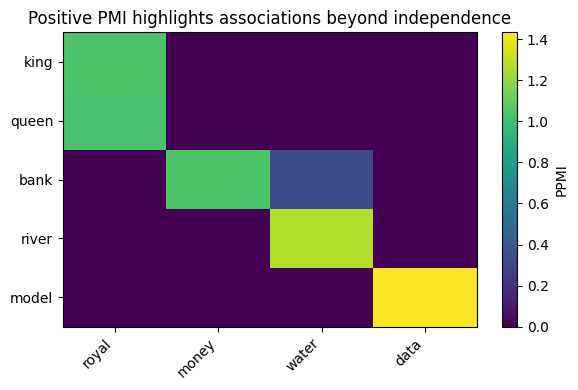

In [14]:
plt.figure(figsize=(6, 4))
plt.imshow(PPMI, aspect="auto")
plt.xticks(range(len(contexts)), contexts, rotation=45, ha="right")
plt.yticks(range(len(words)), words)
plt.colorbar(label="PPMI")
plt.title("Positive PMI highlights associations beyond independence")
plt.tight_layout()
plt.show()


### Exercise 5

Modify the count table so that the context `data` becomes extremely common for every word. What happens to the PMI value for `(model, data)`?


## 11. Tokenization changes entropy units

Perplexity is not directly comparable across tokenizers. The same text can be represented as characters, words, or simple subwords. Each representation defines a different sequence.

A more meaningful compression-style comparison is often **bits per original character**:

$$
\text{bits per character}=\frac{\text{total code length in bits}}{\text{number of original characters}}.
$$


In [15]:
text_example = "language models learn language patterns"
char_tokens = list(text_example.replace(" ", "_"))
word_tokens = text_example.split()

# A toy subword tokenizer: split common suffixes and keep spaces implicit.
def toy_subword_tokenize(text):
    pieces = []
    for word in text.split():
        if word.endswith("ing") and len(word) > 4:
            pieces.extend([word[:-3], "##ing"])
        elif word.endswith("s") and len(word) > 3:
            pieces.extend([word[:-1], "##s"])
        else:
            pieces.append(word)
    return pieces

subword_tokens = toy_subword_tokenize(text_example)

for name, toks in [("characters", char_tokens), ("words", word_tokens), ("toy subwords", subword_tokens)]:
    c = Counter(toks)
    p_tok = np.array([v / sum(c.values()) for v in c.values()])
    H_bits_tok = entropy(p_tok, base=2)
    total_bits_empirical = len(toks) * H_bits_tok
    bits_per_original_char = total_bits_empirical / len(text_example)
    print(name)
    print("  tokens:", toks)
    print("  number of tokens:", len(toks))
    print("  vocab size:", len(c))
    print("  empirical entropy per token:", round(H_bits_tok, 4), "bits")
    print("  empirical bits per original character:", round(bits_per_original_char, 4))


characters
  tokens: ['l', 'a', 'n', 'g', 'u', 'a', 'g', 'e', '_', 'm', 'o', 'd', 'e', 'l', 's', '_', 'l', 'e', 'a', 'r', 'n', '_', 'l', 'a', 'n', 'g', 'u', 'a', 'g', 'e', '_', 'p', 'a', 't', 't', 'e', 'r', 'n', 's']
  number of tokens: 39
  vocab size: 14
  empirical entropy per token: 3.5644 bits
  empirical bits per original character: 3.5644
words
  tokens: ['language', 'models', 'learn', 'language', 'patterns']
  number of tokens: 5
  vocab size: 4
  empirical entropy per token: 1.9219 bits
  empirical bits per original character: 0.2464
toy subwords
  tokens: ['language', 'model', '##s', 'learn', 'language', 'pattern', '##s']
  number of tokens: 7
  vocab size: 5
  empirical entropy per token: 2.2359 bits
  empirical bits per original character: 0.4013


### Exercise 6

Create another text example with rare long words. Compare word tokens, character tokens, and toy subwords. Explain why entropy per token and bits per character tell different stories.


## 12. KL regularization as a distributional trust region

In fine-tuning and alignment, a model distribution $\pi_\theta$ is often regularized toward a reference distribution $\pi_0$:

$$
\text{reward objective} - \beta D_{KL}(\pi_\theta \| \pi_0).
$$

The KL term is a **distributional trust region**. It does not directly measure parameter distance; it measures change in output probabilities.


In [16]:
responses = ["concise answer", "detailed answer", "refuse", "ask clarification"]
pi0 = np.array([0.40, 0.35, 0.15, 0.10])
reward = np.array([0.6, 1.2, -0.3, 0.2])

# Candidate fine-tuned policies.
candidates = {
    "near reference": np.array([0.36, 0.42, 0.12, 0.10]),
    "reward seeking": np.array([0.10, 0.82, 0.03, 0.05]),
    "mode collapse": np.array([0.02, 0.95, 0.01, 0.02]),
}

rows = []
for name, pi in candidates.items():
    expected_reward = float(np.sum(pi * reward))
    kl_to_ref = kl_divergence(pi, pi0)
    for beta in [0.0, 0.2, 1.0]:
        objective = expected_reward - beta * kl_to_ref
        rows.append({
            "candidate": name,
            "beta": beta,
            "expected reward": expected_reward,
            "KL(pi || pi0)": kl_to_ref,
            "regularized objective": objective,
        })

policy_df = pd.DataFrame(rows)
display(policy_df.round(4))

prob_df = pd.DataFrame(candidates, index=responses)
prob_df.insert(0, "reference", pi0)
display(prob_df.round(3))


,candidate,beta,expected reward,KL(pi || pi0),regularized objective
0,near reference,0.0,0.704,0.0119,0.7040
1,near reference,0.2,0.704,0.0119,0.7016
2,near reference,1.0,0.704,0.0119,0.6921
3,reward seeking,0.0,1.045,0.4766,1.0450
4,reward seeking,0.2,1.045,0.4766,0.9497
5,reward seeking,1.0,1.045,0.4766,0.5684
6,mode collapse,0.0,1.153,0.8294,1.1530
7,mode collapse,0.2,1.153,0.8294,0.9871
8,mode collapse,1.0,1.153,0.8294,0.3236


,reference,near reference,reward seeking,mode collapse
concise answer,0.40,0.36,0.10,0.02
detailed answer,0.35,0.42,0.82,0.95
refuse,0.15,0.12,0.03,0.01
ask clarification,0.10,0.10,0.05,0.02


### Exercise 7

For each value of $\beta$, which candidate policy is preferred by the regularized objective? Explain the tradeoff between reward and staying close to the reference distribution.


## 13. Information bottleneck viewpoint

A representation $Z$ should preserve information useful for predicting $Y$ while discarding irrelevant details of $X$.

An idealized information bottleneck objective is

$$
I(X;Z)-\beta I(Z;Y).
$$

In this section, we compute mutual information for two toy representations.


In [17]:
# Four input types X and two labels Y.
# X=0,1 are positive-like; X=2,3 are negative-like.
p_x = np.array([0.25, 0.25, 0.25, 0.25])
y_given_x = np.array([
    [0.10, 0.90],  # mostly positive
    [0.20, 0.80],
    [0.85, 0.15],  # mostly negative
    [0.90, 0.10],
])

# Representation A keeps all four input types.
zA_given_x = np.eye(4)
# Representation B compresses into two clusters: positive-like and negative-like.
zB_given_x = np.array([
    [1, 0],
    [1, 0],
    [0, 1],
    [0, 1],
], dtype=float)
# Representation C discards almost everything.
zC_given_x = np.array([
    [1],
    [1],
    [1],
    [1],
], dtype=float)


def mutual_information_joint(joint):
    joint = np.asarray(joint, dtype=float)
    joint = joint / joint.sum()
    px = joint.sum(axis=1, keepdims=True)
    py = joint.sum(axis=0, keepdims=True)
    prod = px @ py
    mask = joint > 0
    return float(np.sum(joint[mask] * np.log(joint[mask] / prod[mask])))


def compute_IXZ_IZY(p_x, y_given_x, z_given_x):
    # joint X,Z
    p_xz = p_x[:, None] * z_given_x
    IXZ = mutual_information_joint(p_xz)

    # joint Z,Y = sum_x p(x) p(z|x) p(y|x)
    p_zy = z_given_x.T @ (p_x[:, None] * y_given_x)
    IZY = mutual_information_joint(p_zy)
    return IXZ, IZY

rows = []
for name, zgx in [("A: keep input type", zA_given_x), ("B: useful compression", zB_given_x), ("C: collapse", zC_given_x)]:
    IXZ, IZY = compute_IXZ_IZY(p_x, y_given_x, zgx)
    rows.append({
        "representation": name,
        "I(X;Z) compression cost": IXZ,
        "I(Z;Y) predictive information": IZY,
        "IB objective beta=2": IXZ - 2 * IZY,
    })

display(pd.DataFrame(rows).round(4))


,representation,I(X;Z) compression cost,I(Z;Y) predictive information,IB objective beta=2
0,A: keep input type,1.3863,0.2995,0.7873
1,B: useful compression,0.6931,0.2931,0.1070
2,C: collapse,0.0000,0.0000,0.0000


### Exercise 8

Which representation has the best value of $I(X;Z)-2I(Z;Y)$? Why is the collapsed representation not useful even though it is maximally compressed?


## 14. Rare-event instability of PMI

PMI can be very large for rare events. This is why practical systems often use smoothing, minimum-count thresholds, or PPMI before factorization.


In [18]:
# Create two word-context pairs with the same observed count but different marginal frequencies.
rare_table = pd.DataFrame({
    "pair": ["rare_word, rare_context", "common_word, common_context"],
    "p(w,c)": [1/10000, 1/10000],
    "p(w)": [1/1000, 1/5],
    "p(c)": [1/1000, 1/5],
})
rare_table["PMI"] = np.log(rare_table["p(w,c)"] / (rare_table["p(w)"] * rare_table["p(c)"]))
rare_table["PMI bits"] = rare_table["PMI"] / math.log(2)
display(rare_table.round(4))


,pair,"p(w,c)",p(w),p(c),PMI,PMI bits
0,"rare_word, rare_context",0.0001,0.001,0.001,4.6052,6.6439
1,"common_word, common_context",0.0001,0.200,0.200,-5.9915,-8.6439


### Interpretation

The rare pair has high PMI because it occurs much more often than independence predicts, even though it may be based on very little evidence. A high PMI value is not automatically a reliable semantic fact.


## 15. A small information-theoretic dashboard for a corpus

The next function summarizes a corpus using entropy, perplexity, vocabulary size, bigram conditional entropy, and top high-PMI word-context pairs.


In [19]:
def corpus_information_profile(text, window=2, alpha=0.5, min_count=1, top_k=10):
    toks = tokenize(text)
    counts = Counter(toks)
    vocab_local = sorted(counts)
    p_uni = np.array([counts[w] / len(toks) for w in vocab_local])
    H_uni = entropy(p_uni)

    # Bigram conditional entropy.
    if len(toks) >= 2:
        vocab_bi, bi_counts, prev_counts = build_bigram_counts(toks)
        idx = {w: i for i, w in enumerate(vocab_bi)}
        d_local = len(vocab_bi)
        C_local = np.zeros((d_local, d_local))
        for (a, b), c in bi_counts.items():
            C_local[idx[a], idx[b]] = c
        P_local = (C_local + alpha) / (C_local.sum(axis=1, keepdims=True) + alpha * d_local)
        pi_local = np.array([prev_counts[w] for w in vocab_bi], dtype=float)
        pi_local = pi_local / pi_local.sum()
        H_rows = np.array([entropy(row) for row in P_local])
        H_bigram = float(np.sum(pi_local * H_rows))
    else:
        H_bigram = float("nan")

    # Word-context co-occurrence counts.
    pair_counts = Counter()
    center_counts = Counter()
    context_counts = Counter()
    for i, w in enumerate(toks):
        center_counts[w] += 1
        lo = max(0, i - window)
        hi = min(len(toks), i + window + 1)
        for j in range(lo, hi):
            if j != i:
                c = toks[j]
                pair_counts[(w, c)] += 1
                context_counts[c] += 1

    total_pairs = sum(pair_counts.values())
    pmi_rows = []
    for (w, c), pair_count in pair_counts.items():
        if pair_count < min_count:
            continue
        pwc = pair_count / total_pairs
        pw = center_counts[w] / len(toks)
        pc = context_counts[c] / total_pairs
        pmi = math.log(pwc / (pw * pc))
        pmi_rows.append({"word": w, "context": c, "count": pair_count, "PMI": pmi, "PPMI": max(pmi, 0.0)})
    pmi_df = pd.DataFrame(pmi_rows).sort_values("PMI", ascending=False).head(top_k)

    summary = {
        "tokens": len(toks),
        "vocabulary_size": len(vocab_local),
        "unigram_entropy_nats": H_uni,
        "unigram_perplexity": math.exp(H_uni),
        "bigram_conditional_entropy_nats": H_bigram,
        "bigram_conditional_perplexity": math.exp(H_bigram) if math.isfinite(H_bigram) else float("nan"),
    }
    return summary, pmi_df

summary, pmi_profile = corpus_information_profile(corpus, window=2, alpha=0.5, min_count=1, top_k=12)
print("Corpus information profile")
for k, v in summary.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print("\nTop PMI pairs")
display(pmi_profile.round(3))


Corpus information profile
  tokens: 36
  vocabulary_size: 29
  unigram_entropy_nats: 3.2994
  unigram_perplexity: 27.0971
  bigram_conditional_entropy_nats: 3.3134
  bigram_conditional_perplexity: 27.4780

Top PMI pairs


,word,context,count,PMI,PPMI
9,patterns,models,1,2.485,2.485
6,learn,models,1,2.485,2.485
8,learn,from,1,2.197,2.197
7,learn,patterns,1,2.197,2.197
4,models,patterns,1,2.197,2.197
3,models,learn,1,2.197,2.197
46,and,compression,1,2.197,2.197
47,and,prediction,1,2.197,2.197
49,prediction,compression,1,2.197,2.197
50,prediction,and,1,2.197,2.197


## 16. AI-assisted learning prompts

Use an AI assistant as a mathematical discussion partner. Ask it to verify calculations, expose assumptions, and check edge cases.

### Prompt 1: entropy audit

```text
For p = [0.5, 0.25, 0.15, 0.10], compute entropy in nats and bits.
Show every step and explain why rare tokens have larger surprisal.
```

### Prompt 2: cross-entropy versus KL divergence

```text
Explain the identity H(p,q) = H(p) + KL(p || q) for p = [0.5,0.3,0.2] and q = [0.4,0.4,0.2].
Do the arithmetic and explain why minimizing cross-entropy over q is equivalent to minimizing KL divergence.
```

### Prompt 3: tokenization caution

```text
A paper reports that model A has perplexity 25 using a word tokenizer and model B has perplexity 12 using a subword tokenizer.
Can we conclude that model B is better? Give a careful information-theoretic answer.
```

### Prompt 4: PMI instability

```text
Create a tiny co-occurrence example where PMI is high because both events are rare.
Explain why this may be statistically unstable.
```


## 17. Common mistakes to avoid

1. **Confusing entropy and cross-entropy.** Entropy uses $p$ in both places. Cross-entropy uses $p$ in the expectation and $q$ inside the log.
2. **Ignoring support mismatch.** If $p_j>0$ and $q_j=0$, cross-entropy and KL divergence are infinite.
3. **Treating KL divergence as a metric.** KL is asymmetric and does not satisfy the triangle inequality.
4. **Comparing perplexity across tokenizers.** Perplexity depends on the prediction unit.
5. **Overinterpreting PMI for rare events.** High PMI can come from small counts.
6. **Forgetting the logarithm base.** Natural logs give nats. Base-$2$ logs give bits.
7. **Assuming low entropy means high semantic quality.** Entropy measures uncertainty, not correctness or helpfulness by itself.


## 18. Exercises

### Conceptual exercises

1. Explain why entropy is maximized by the uniform distribution on a finite vocabulary.
2. Explain why cross-entropy is always at least entropy.
3. Give an example showing that $D_{KL}(p \| q) \ne D_{KL}(q \| p)$.
4. Explain why perplexity cannot be compared directly across different tokenizers.
5. Interpret $I(X;Y)=0$ in terms of independence.
6. Explain why PMI can be unstable for rare events.

### Computational exercises

7. Write one function that returns entropy, cross-entropy, KL divergence, and perplexity for two discrete distributions.
8. Given a small corpus, compute unigram entropy and bigram conditional entropy. Which is smaller? Why?
9. Build a word-context matrix for a small corpus and compute PMI and PPMI.
10. For a binary text classification data set, compute mutual information between each token and the class label.
11. Compare two toy language models by average bits per token on a held-out sequence.
12. Simulate distributions with increasing vocabulary size and plot entropy as the distribution becomes more uniform.

### Mathematical exercises

13. Prove Gibbs inequality using Jensen's inequality.
14. Prove the entropy chain rule for two variables: $H(X,Y)=H(X)+H(Y \mid X)$.
15. Show that $I(X;Y)=H(X)+H(Y)-H(X,Y)$.
16. Show that $I(X;Y)=D_{KL}(p(x,y) \| p(x)p(y))$.
17. State the data processing inequality and interpret it for NLP representations.
18. For a Markov chain with transition matrix $P$ and stationary distribution $\pi$, derive the entropy rate formula $\sum_i \pi_i H(P_{i,\cdot})$.


## 19. Mini-project: information profile of a corpus

Choose a small corpus such as course descriptions, news headlines, paper abstracts, or student advising questions. Build an information-theoretic profile of the corpus.

Your report should include:

1. unigram token distribution and entropy;
2. entropy as a function of vocabulary truncation;
3. bigram conditional entropy;
4. a PMI or PPMI word-context table;
5. a comparison of at least two simple language models by cross-entropy and perplexity;
6. a discussion of how tokenization changes the numerical values;
7. a short reflection on what information theory captures and what it misses.

A good final paragraph should distinguish mathematical uncertainty from semantic quality, factuality, fairness, and usefulness.


## 20. Lab summary

In this lab, you built the main information-theoretic quantities used in NLP:

- entropy as average uncertainty;
- cross-entropy as expected model log loss;
- KL divergence as extra code length from using the wrong distribution;
- perplexity as exponential average uncertainty;
- conditional entropy as uncertainty after context;
- mutual information as dependence beyond independence;
- PMI as a local co-occurrence association score;
- KL regularization as a trust region for output distributions.

These ideas will reappear in optimization, graph-based language models, topology and geometry of representations, and ethical evaluation.
